# Graph V

In [9]:
from langgraph.graph import StateGraph, START
import random
from typing import Dict, List, TypedDict

In [20]:
class AgentState(TypedDict):
    player_name: str = "Student"
    guesses: list = []
    attempts: int = 0
    lower_bound: int = 1
    upper_bound: int = 20 
    number: int
    hint: str

In [21]:
def setup_node(state: AgentState) -> AgentState:
    state["number"] = random.randint(state["lower_bound"], state["upper_bound"])
    return state

def guess_node(state: AgentState) -> AgentState:
    state["guesses"].append(random.randint(state["lower_bound"], state["upper_bound"]))
    state["attempts"] += 1
    return state

def hint_node(state: AgentState) -> AgentState:
    if state["guesses"][-1] == state["number"]:
        print(f"Correctly guessed number was {state['number']}")
        state['hint'] = "correct"
        return state
    if state["guesses"][-1] > state["number"]:
        state['hint'] = "lower"
        state["upper_bound"] = state['guesses'][-1] - 1
        return state
    if state["guesses"][-1] < state["number"]:
        state['hint'] = "higher"
        state["lower_bound"] = state['guesses'][-1] + 1
        return state
    
    raise Exception("Out of bounds")

def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""
    if state["attempts"] > 7 :
        print("Too many guesses")
        return "exit"  # Exit the loop
    if state['hint'] == "correct":
        return "exit"  # Exit the loop
    return "loop"

In [22]:
graph = StateGraph(AgentState)

graph.add_node("setup", setup_node)
graph.add_node("guess", guess_node)
graph.add_node("hint", hint_node)

graph.set_entry_point("setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")
graph.add_conditional_edges(
    "hint",     # Source node
    should_continue, # Action
    {
        "loop": "guess",  
        "exit": END          
    }
)


app = graph.compile()

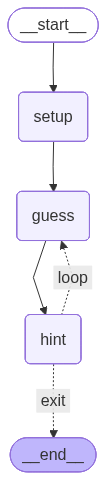

In [23]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [26]:
app.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20})

Correctly guessed number was 4


{'player_name': 'Student',
 'guesses': [16, 2, 5, 4],
 'attempts': 4,
 'lower_bound': 3,
 'upper_bound': 4,
 'number': 4,
 'hint': 'correct'}